In [1]:
# Import python libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Set style for better visualizations
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Load the data
df = pd.read_csv(r"C:\Users\DELL\Downloads\housing.csv")
df

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY
...,...,...,...,...,...,...,...,...,...,...
20635,-121.09,39.48,25.0,1665.0,374.0,845.0,330.0,1.5603,78100.0,INLAND
20636,-121.21,39.49,18.0,697.0,150.0,356.0,114.0,2.5568,77100.0,INLAND
20637,-121.22,39.43,17.0,2254.0,485.0,1007.0,433.0,1.7000,92300.0,INLAND
20638,-121.32,39.43,18.0,1860.0,409.0,741.0,349.0,1.8672,84700.0,INLAND


In [2]:
# Check for missing values more thoroughly
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


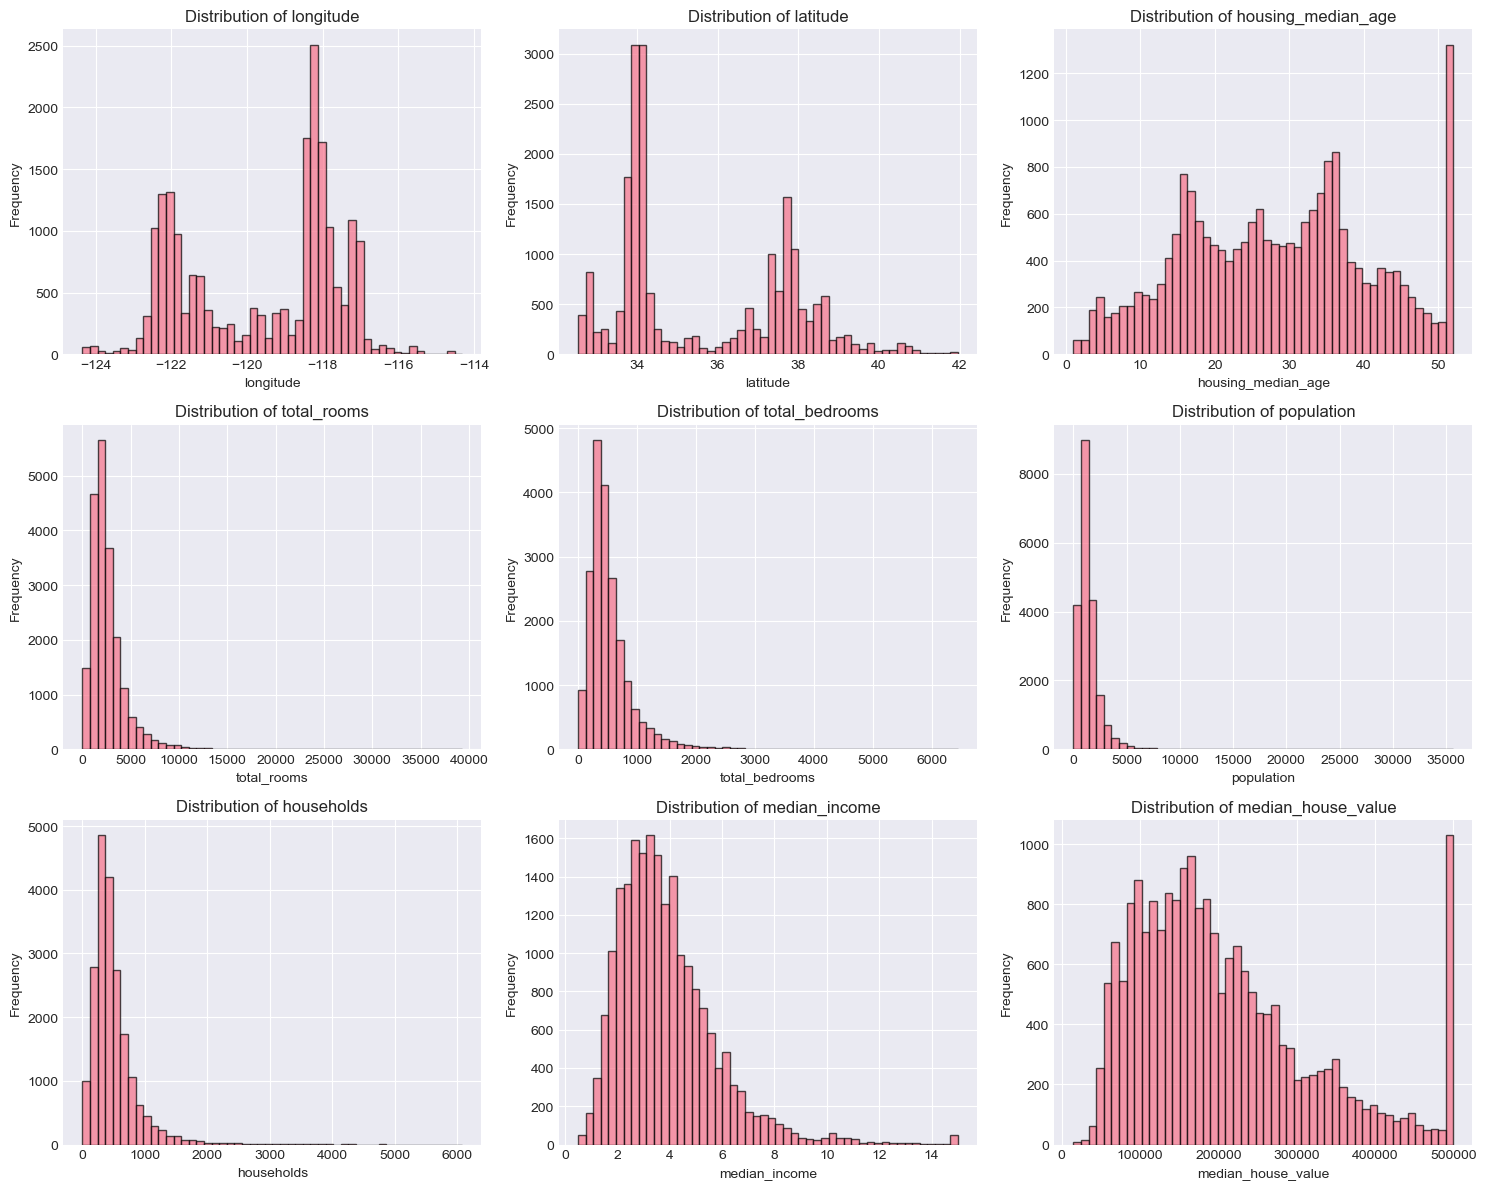

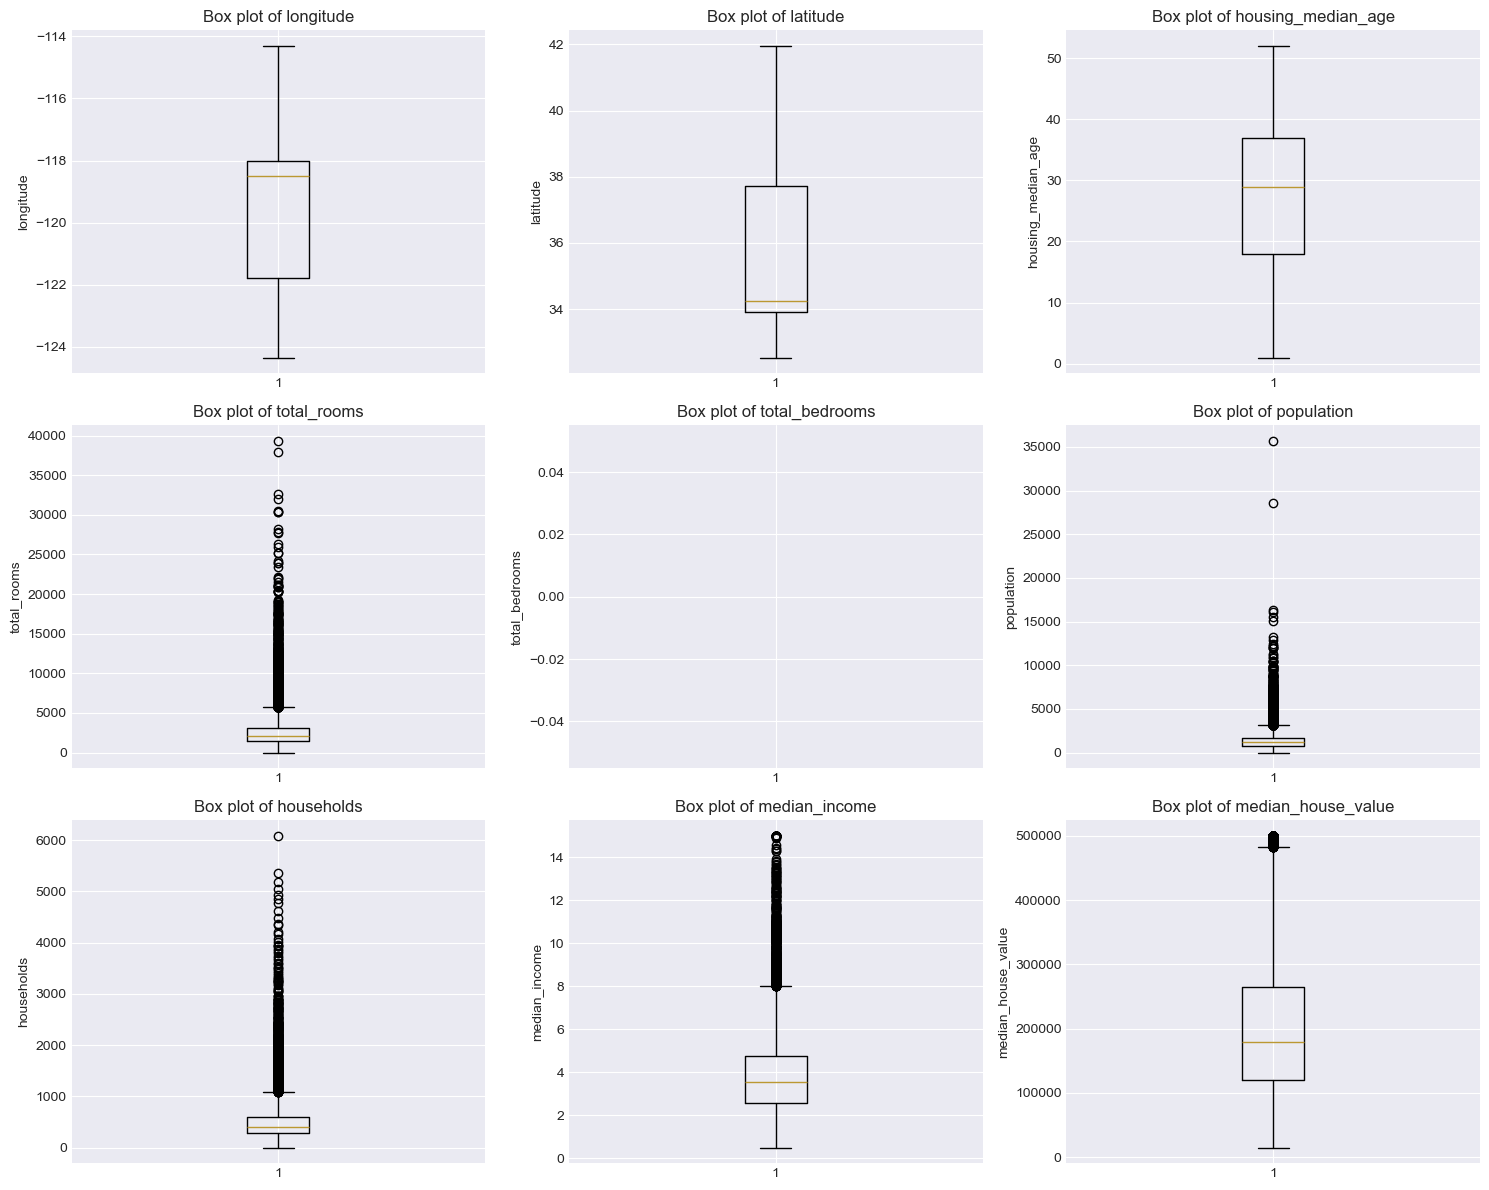

In [3]:
# Create a figure with multiple subplots for distributions
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.ravel()

# Plot distributions of numerical features
numerical_cols = df.select_dtypes(include=[np.number]).columns
for i, col in enumerate(numerical_cols[:9]):  # Plot first 9 numerical columns
    axes[i].hist(df[col], bins=50, edgecolor='black', alpha=0.7)
    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

# Box plots to identify outliers
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.ravel()

for i, col in enumerate(numerical_cols[:9]):
    axes[i].boxplot(df[col])
    axes[i].set_title(f'Box plot of {col}')
    axes[i].set_ylabel(col)

plt.tight_layout()
plt.show()

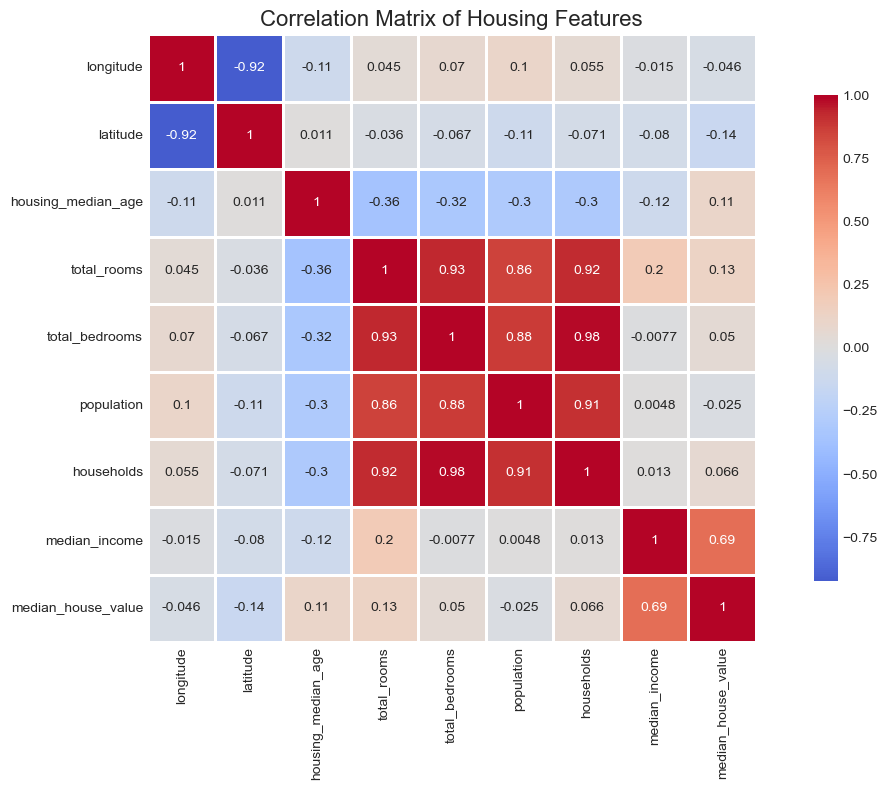


CORRELATIONS WITH MEDIAN HOUSE VALUE
median_house_value    1.000000
median_income         0.688075
total_rooms           0.134153
housing_median_age    0.105623
households            0.065843
total_bedrooms        0.049686
population           -0.024650
longitude            -0.045967
latitude             -0.144160
Name: median_house_value, dtype: float64


In [4]:
# Correlation matrix
plt.figure(figsize=(12, 8))
correlation_matrix = df.select_dtypes(include=[np.number]).corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, 
            square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Correlation Matrix of Housing Features', fontsize=16)
plt.tight_layout()
plt.show()

# Focus on correlations with median_house_value
print("\n" + "="*50)
print("CORRELATIONS WITH MEDIAN HOUSE VALUE")
print("="*50)
target_correlations = correlation_matrix['median_house_value'].sort_values(ascending=False)
print(target_correlations)

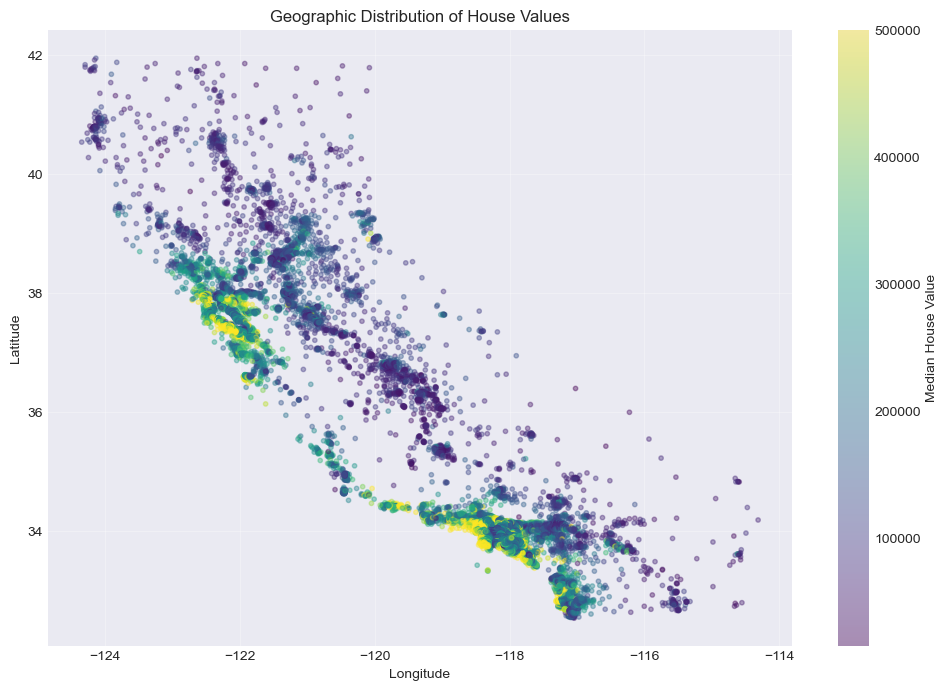

<Figure size 1200x600 with 0 Axes>

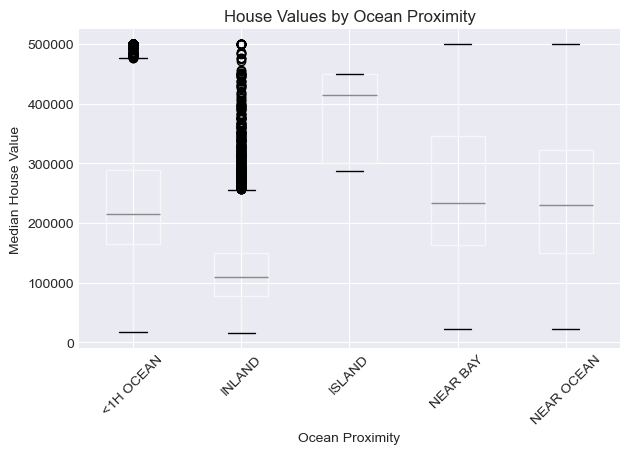

In [5]:
# Scatter plot of locations colored by house value
plt.figure(figsize=(12, 8))
scatter = plt.scatter(df['longitude'], df['latitude'], 
                      c=df['median_house_value'], 
                      cmap='viridis', alpha=0.4, s=10)
plt.colorbar(scatter, label='Median House Value')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Geographic Distribution of House Values')
plt.grid(True, alpha=0.3)
plt.show()

# Analysis by ocean proximity
plt.figure(figsize=(12, 6))
df.boxplot(column='median_house_value', by='ocean_proximity', rot=45)
plt.title('House Values by Ocean Proximity')
plt.suptitle('')
plt.xlabel('Ocean Proximity')
plt.ylabel('Median House Value')
plt.tight_layout()
plt.show()

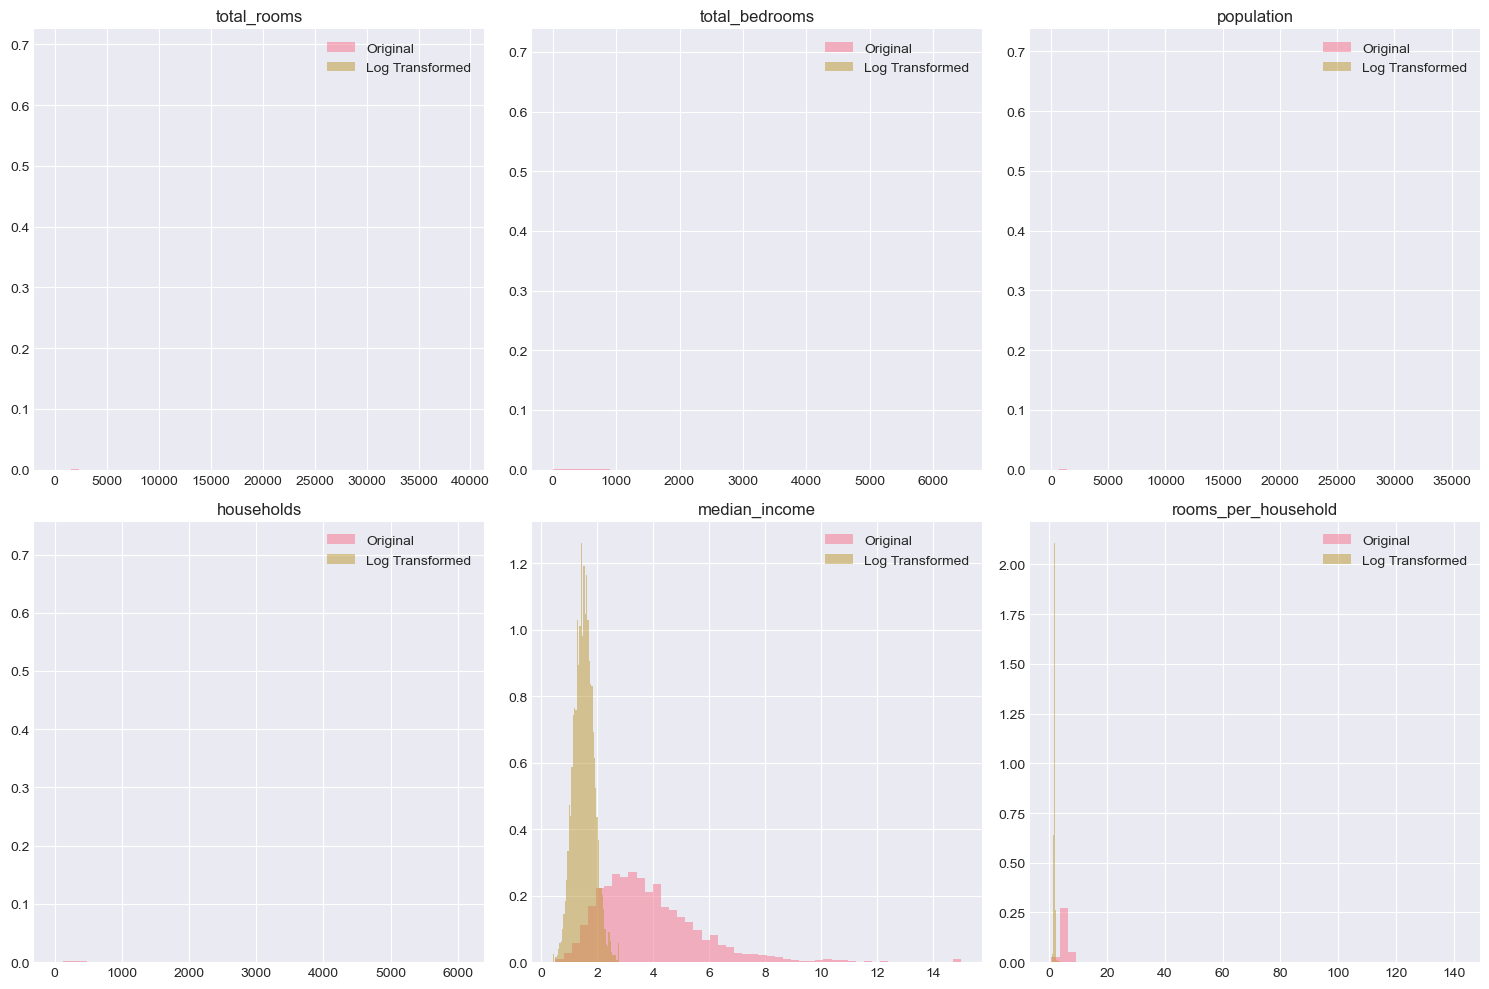

In [6]:
# Create new features
df['rooms_per_household'] = df['total_rooms'] / df['households']
df['bedrooms_per_room'] = df['total_bedrooms'] / df['total_rooms']
df['population_per_household'] = df['population'] / df['households']

# Log transform skewed features
from scipy.stats import skew

skewed_features = ['total_rooms', 'total_bedrooms', 'population', 'households', 
                   'median_income', 'rooms_per_household']

for feature in skewed_features:
    df[f'log_{feature}'] = np.log1p(df[feature])

# Visualize the effect of log transformation
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.ravel()

for i, feature in enumerate(skewed_features[:6]):
    axes[i].hist(df[feature], bins=50, alpha=0.5, label='Original', density=True)
    axes[i].hist(df[f'log_{feature}'], bins=50, alpha=0.5, label='Log Transformed', density=True)
    axes[i].set_title(f'{feature}')
    axes[i].legend()

plt.tight_layout()
plt.show()

In [7]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Separate features and target
X = df.drop('median_house_value', axis=1)
y = df['median_house_value']

# Split the data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training set size: {X_train.shape}")
print(f"Test set size: {X_test.shape}")

# Identify column types
numerical_features = X.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = X.select_dtypes(include=['object']).columns.tolist()

print(f"\nNumerical features: {len(numerical_features)}")
print(f"Categorical features: {len(categorical_features)}")

Training set size: (16512, 18)
Test set size: (4128, 18)

Numerical features: 17
Categorical features: 1


In [8]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer  # Import imputer to handle missing values
import numpy as np

# Create preprocessing pipelines with imputation for missing values
numerical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean')),  # Add imputer for numerical features
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),  # Add imputer for categorical features
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_features),
        ('cat', categorical_transformer, categorical_features)
    ])

# Define models to try
models = {
    'Linear Regression': LinearRegression(),
    'Ridge Regression': Ridge(alpha=1.0),
    'Lasso Regression': Lasso(alpha=1.0),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=42)
}

# Train and evaluate each model
results = {}

for name, model in models.items():
    # Create pipeline
    pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('regressor', model)
    ])
    
    # Train the model
    pipeline.fit(X_train, y_train)
    
    # Make predictions
    y_pred_train = pipeline.predict(X_train)
    y_pred_test = pipeline.predict(X_test)
    
    # Calculate metrics
    train_rmse = np.sqrt(mean_squared_error(y_train, y_pred_train))
    test_rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))
    train_r2 = r2_score(y_train, y_pred_train)
    test_r2 = r2_score(y_test, y_pred_test)
    test_mae = mean_absolute_error(y_test, y_pred_test)
    
    results[name] = {
        'Train RMSE': train_rmse,
        'Test RMSE': test_rmse,
        'Train R2': train_r2,
        'Test R2': test_r2,
        'Test MAE': test_mae
    }
    
    print(f"\n{name}:")
    print(f"  Train RMSE: ${train_rmse:,.2f}")
    print(f"  Test RMSE: ${test_rmse:,.2f}")
    print(f"  Train R²: {train_r2:.4f}")
    print(f"  Test R²: {test_r2:.4f}")
    print(f"  Test MAE: ${test_mae:,.2f}")


Linear Regression:
  Train RMSE: $65,557.12
  Test RMSE: $67,063.23
  Train R²: 0.6785
  Test R²: 0.6568
  Test MAE: $48,650.90

Ridge Regression:
  Train RMSE: $65,558.04
  Test RMSE: $67,078.20
  Train R²: 0.6785
  Test R²: 0.6566
  Test MAE: $48,661.60

Lasso Regression:
  Train RMSE: $65,557.22
  Test RMSE: $67,051.92
  Train R²: 0.6785
  Test R²: 0.6569
  Test MAE: $48,633.80

Random Forest:
  Train RMSE: $18,584.74
  Test RMSE: $49,914.33
  Train R²: 0.9742
  Test R²: 0.8099
  Test MAE: $32,000.02

Gradient Boosting:
  Train RMSE: $50,289.58
  Test RMSE: $53,496.80
  Train R²: 0.8108
  Test R²: 0.7816
  Test MAE: $36,405.00


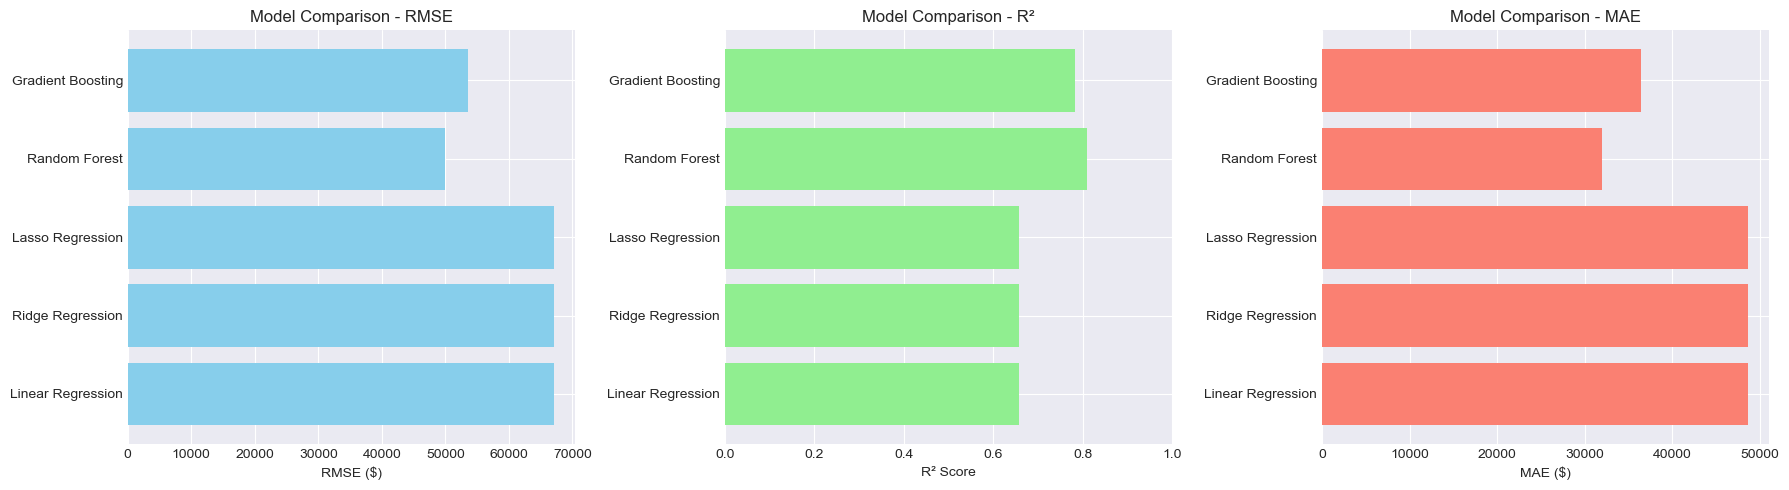

In [9]:
# Create comparison dataframe
results_df = pd.DataFrame(results).T

# Plot comparison
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# RMSE comparison
axes[0].barh(results_df.index, results_df['Test RMSE'], color='skyblue')
axes[0].set_xlabel('RMSE ($)')
axes[0].set_title('Model Comparison - RMSE')

# R² comparison
axes[1].barh(results_df.index, results_df['Test R2'], color='lightgreen')
axes[1].set_xlabel('R² Score')
axes[1].set_title('Model Comparison - R²')
axes[1].set_xlim(0, 1)

# MAE comparison
axes[2].barh(results_df.index, results_df['Test MAE'], color='salmon')
axes[2].set_xlabel('MAE ($)')
axes[2].set_title('Model Comparison - MAE')

plt.tight_layout()
plt.show()

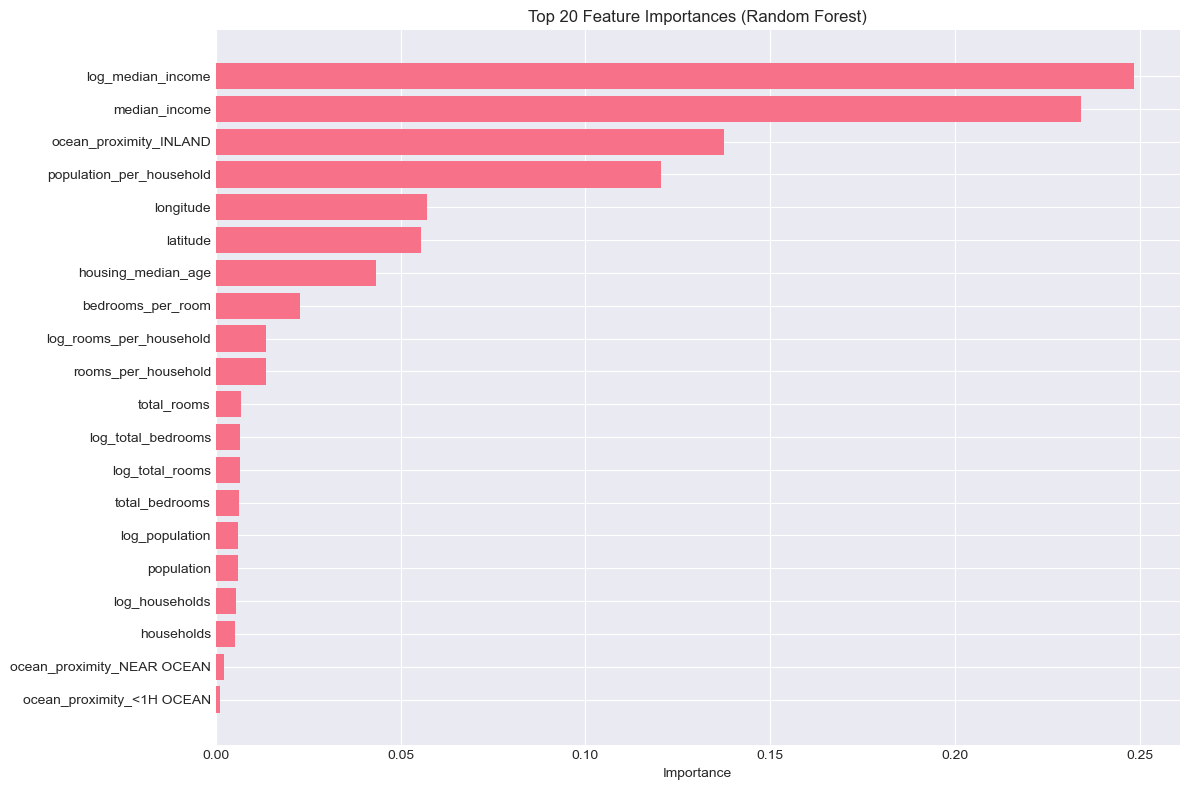

In [10]:
# Get feature importance from Random Forest
rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(n_estimators=100, random_state=42))
])
rf_pipeline.fit(X_train, y_train)

# Get feature names after preprocessing
feature_names = (numerical_features + 
                 list(rf_pipeline.named_steps['preprocessor']
                      .named_transformers_['cat']
                      .get_feature_names_out(categorical_features)))

# Get feature importance
importances = rf_pipeline.named_steps['regressor'].feature_importances_
feature_importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
}).sort_values('importance', ascending=False)

# Plot top 20 features
plt.figure(figsize=(12, 8))
top_features = feature_importance_df.head(20)
plt.barh(range(len(top_features)), top_features['importance'].values)
plt.yticks(range(len(top_features)), top_features['feature'].values)
plt.xlabel('Importance')
plt.title('Top 20 Feature Importances (Random Forest)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

Best model: Random Forest


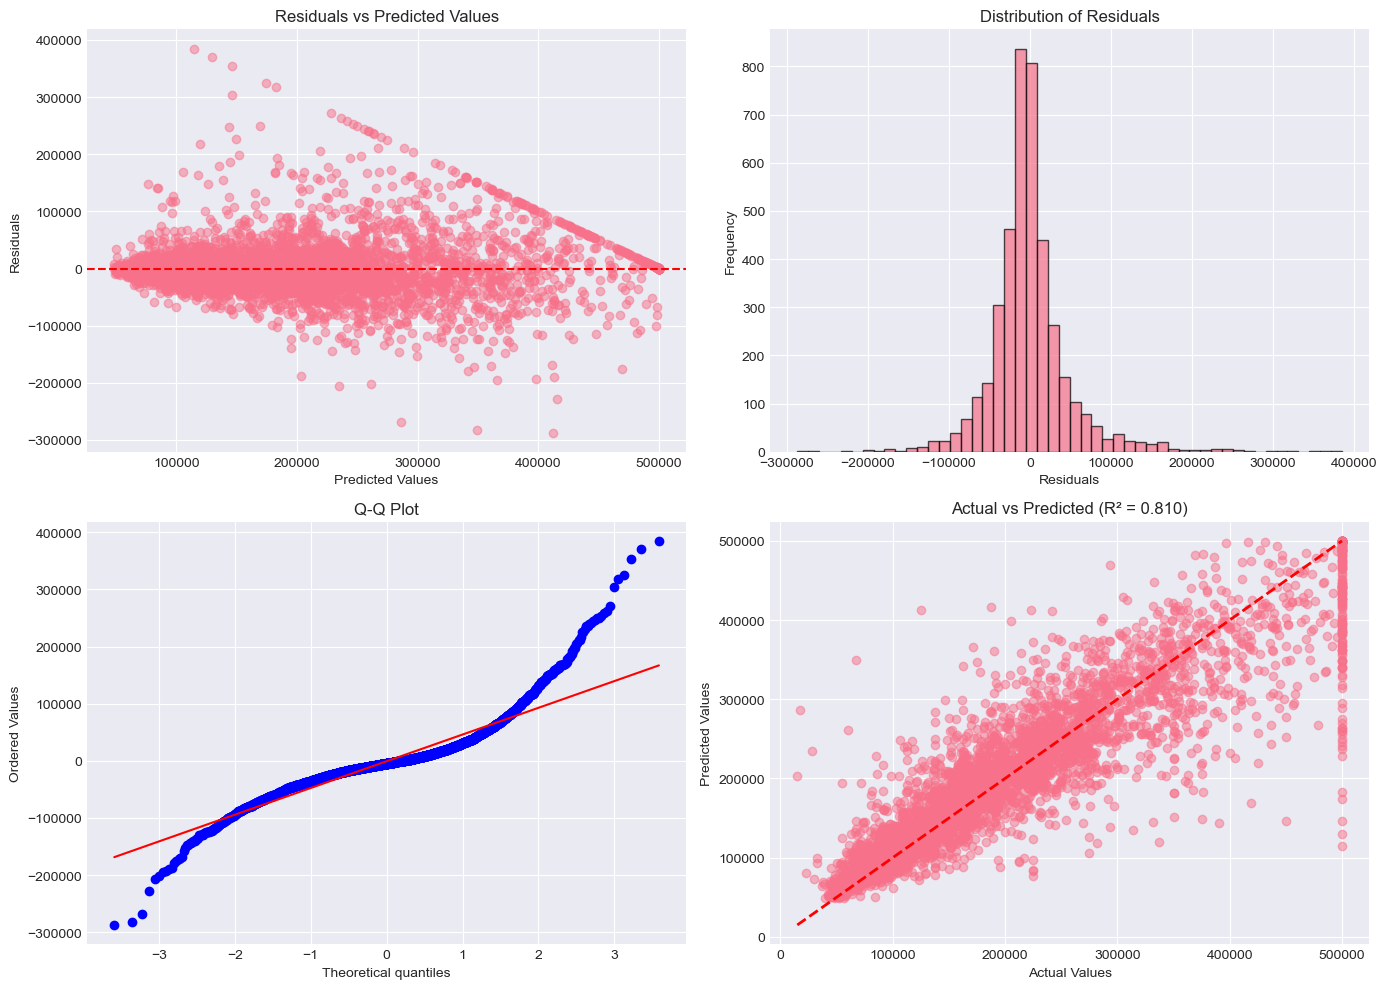

In [11]:
# Use best model (likely Random Forest or Gradient Boosting)
best_model_name = results_df['Test R2'].idxmax()
print(f"Best model: {best_model_name}")

best_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', models[best_model_name])
])
best_pipeline.fit(X_train, y_train)
y_pred = best_pipeline.predict(X_test)

# Residual plot
residuals = y_test - y_pred

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Residuals vs Predicted
axes[0, 0].scatter(y_pred, residuals, alpha=0.5)
axes[0, 0].axhline(y=0, color='red', linestyle='--')
axes[0, 0].set_xlabel('Predicted Values')
axes[0, 0].set_ylabel('Residuals')
axes[0, 0].set_title('Residuals vs Predicted Values')

# Distribution of residuals
axes[0, 1].hist(residuals, bins=50, edgecolor='black', alpha=0.7)
axes[0, 1].set_xlabel('Residuals')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].set_title('Distribution of Residuals')

# Q-Q plot
from scipy import stats
stats.probplot(residuals, dist="norm", plot=axes[1, 0])
axes[1, 0].set_title('Q-Q Plot')

# Actual vs Predicted
axes[1, 1].scatter(y_test, y_pred, alpha=0.5)
axes[1, 1].plot([y_test.min(), y_test.max()], 
                [y_test.min(), y_test.max()], 
                'r--', lw=2)
axes[1, 1].set_xlabel('Actual Values')
axes[1, 1].set_ylabel('Predicted Values')
axes[1, 1].set_title(f'Actual vs Predicted (R² = {results_df.loc[best_model_name, "Test R2"]:.3f})')

plt.tight_layout()
plt.show()

In [ ]:
from sklearn.model_selection import GridSearchCV

# Tune Random Forest
param_grid = {
    'regressor__n_estimators': [50, 100, 200],
    'regressor__max_depth': [None, 10, 20, 30],
    'regressor__min_samples_split': [2, 5, 10],
    'regressor__min_samples_leaf': [1, 2, 4]
}

rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(random_state=42))
])

grid_search = GridSearchCV(rf_pipeline, param_grid, cv=5, 
                          scoring='r2', n_jobs=-1, verbose=1)
grid_search.fit(X_train, y_train)

print("Best parameters:", grid_search.best_params_)
print("Best cross-validation score:", grid_search.best_score_)

# Evaluate tuned model
y_pred_tuned = grid_search.predict(X_test)
print(f"\nTuned Model Test R²: {r2_score(y_test, y_pred_tuned):.4f}")
print(f"Tuned Model Test RMSE: ${np.sqrt(mean_squared_error(y_test, y_pred_tuned)):,.2f}")

Fitting 5 folds for each of 108 candidates, totalling 540 fits


In [ ]:
import joblib

# Save the best model
best_model = grid_search.best_estimator_
joblib.dump(best_model, 'best_housing_model.pkl')
print("Model saved as 'best_housing_model.pkl'")

# Save preprocessing pipeline
joblib.dump(preprocessor, 'preprocessor.pkl')
print("Preprocessor saved as 'preprocessor.pkl'")

# Save feature names for future reference
feature_names = {
    'numerical': numerical_features,
    'categorical': categorical_features,
    'target': 'median_house_value'
}
joblib.dump(feature_names, 'feature_names.pkl')
print("Feature names saved as 'feature_names.pkl'")

In [ ]:

    def predict_house_value(model, preprocessor, new_data):
    """
    Predict house values for new data
    
    Parameters:
    model: trained model pipeline
    preprocessor: fitted preprocessor
    new_data: DataFrame with same features as training data
    
    Returns:
    predictions: array of predicted house values
    """
    try:
        # Check if new_data is a DataFrame
        if not isinstance(new_data, pd.DataFrame):
            raise TypeError("new_data must be a pandas DataFrame")
            
        # Get required columns - handle different preprocessor types
        if hasattr(preprocessor, 'feature_names_in_'):
            required_columns = preprocessor.feature_names_in_
        elif hasattr(preprocessor, 'get_feature_names_out'):
            required_columns = preprocessor.get_feature_names_out()
        else:
            # If we can't determine columns, just use what's provided
            required_columns = new_data.columns
        
        # Ensure new_data has correct columns
        missing_cols = [col for col in required_columns if col not in new_data.columns]
        if missing_cols:
            raise ValueError(f"Missing columns: {', '.join(missing_cols)}")
        
        # Make prediction
        predictions = model.predict(new_data)
        
        return predictions
        
    except Exception as e:
        print(f"Error making predictions: {str(e)}")
        return None

# Example usage
# Uncomment and run the following lines after you have your model, preprocessor and test data ready:
# sample_data = X_test.iloc[:5]
# predictions = predict_house_value(best_model, preprocessor, sample_data)
# print("Sample predictions:", predictions)

In [ ]:
# Create comprehensive summary report
print("\n" + "="*60)
print("PROJECT SUMMARY REPORT")
print("="*60)

print(f"\nDataset Shape: {df.shape}")
print(f"Training samples: {X_train.shape[0]}")
print(f"Test samples: {X_test.shape[0]}")

print("\nBest Model Performance:")
print(f"Model: {best_model_name}")
print(f"Test R² Score: {results_df.loc[best_model_name, 'Test R2']:.4f}")
print(f"Test RMSE: ${results_df.loc[best_model_name, 'Test RMSE']:,.2f}")
print(f"Test MAE: ${results_df.loc[best_model_name, 'Test MAE']:,.2f}")

print("\nTop 5 Most Important Features:")
for i, row in feature_importance_df.head(5).iterrows():
    print(f"  {i+1}. {row['feature']}: {row['importance']:.4f}")

print("\nModel Performance Comparison:")
print(results_df.round(4).to_string())

# Save report to file
with open('project_summary.txt', 'w') as f:
    f.write("CALIFORNIA HOUSING PROJECT SUMMARY\n")
    f.write("="*50 + "\n\n")
    f.write(f"Dataset Shape: {df.shape}\n")
    f.write(f"Training samples: {X_train.shape[0]}\n")
    f.write(f"Test samples: {X_test.shape[0]}\n\n")
    f.write("Best Model Performance:\n")
    f.write(f"Model: {best_model_name}\n")
    f.write(f"Test R² Score: {results_df.loc[best_model_name, 'Test R2']:.4f}\n")
    f.write(f"Test RMSE: ${results_df.loc[best_model_name, 'Test RMSE']:,.2f}\n")
    f.write(f"Test MAE: ${results_df.loc[best_model_name, 'Test MAE']:,.2f}\n\n")
    f.write("Model Comparison:\n")
    f.write(results_df.round(4).to_string())

print("\nReport saved as 'project_summary.txt'")